<a href="https://colab.research.google.com/github/pmaniraj55/MyWork/blob/MachineLearning/GradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

w: tensor([[0.7678]], requires_grad=True)
b: tensor([[0.1535]], requires_grad=True)
epoch10:w=2.035, b=2.279,loss=6.608
epoch20:w=2.655, b=3.216,loss=1.629
epoch30:w=2.980, b=3.616,loss=0.585
epoch40:w=3.169, b=3.774,loss=0.350
epoch50:w=3.295, b=3.824,loss=0.282
epoch60:w=3.391, b=3.826,loss=0.250
epoch70:w=3.471, b=3.806,loss=0.226
epoch80:w=3.543, b=3.779,loss=0.207
epoch90:w=3.609, b=3.748,loss=0.189
epoch100:w=3.671, b=3.716,loss=0.172
epoch110:w=3.730, b=3.686,loss=0.158
epoch120:w=3.786, b=3.656,loss=0.144
epoch130:w=3.840, b=3.627,loss=0.132
epoch140:w=3.891, b=3.599,loss=0.120
epoch150:w=3.940, b=3.573,loss=0.110
epoch160:w=3.987, b=3.548,loss=0.100
epoch170:w=4.031, b=3.524,loss=0.092
epoch180:w=4.074, b=3.500,loss=0.084


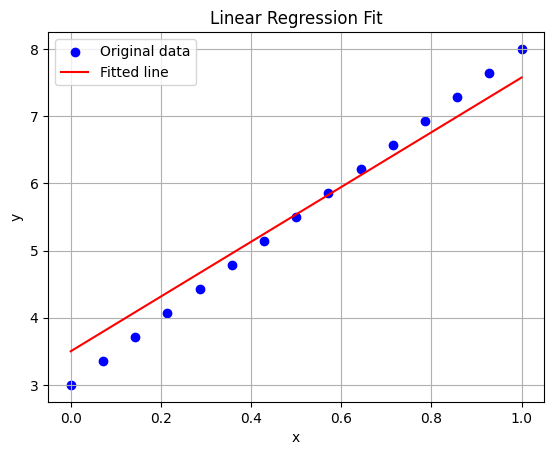

In [4]:
#Generate train data
import torch


x=torch.linspace(0.0,1.0,15).reshape(15,1)
y=5*x+3

w=torch.tensor([5])
b=torch.tensor([3])

#Parameter initialization
w=torch.rand(size=(1,1),requires_grad=True)
b=torch.rand(size=(1,1),requires_grad=True)

#Functions
def forward(x):
  return w*x+b

def loss(y,y_Pred):
  return ((y_Pred-y)**2).mean()

print('w:',w)
print('b:',b)

#Define Hyperparameters
learning_rate=0.03
num_epocs=180

#Train the model

for epoch in range(num_epocs):
  y_pred=forward(x)
  l=loss(y,y_pred) #y -> Ground truth value
  l.backward() #dl/dw - gradient

  with torch.no_grad(): #to skip tracking of operations
    w.data-=learning_rate*w.grad
    b.data-=learning_rate*b.grad
    w.grad.zero_()
    b.grad.zero_()

    if (epoch+1)%10==0:
      print(f'epoch{epoch+1}:w={w.item():.3f}, b={b.item():.3f},loss={l.item():.3f}')


import matplotlib.pyplot as plt

# Switch off gradient tracking for inference
with torch.no_grad():
    predicted = forward(x)

# Plot original data (x vs y)
plt.scatter(x.numpy(), y.numpy(), label='Original data', color='blue')

# Plot predictions (x vs predicted y)
plt.plot(x.numpy(), predicted.numpy(), label='Fitted line', color='red')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()
